# Correlation with Tokyo Weather

## Dataset

Source: Meteostat Hourly API

Location: Tokyo Station area (≈ 35.6812, 139.7671) — timezone Asia/Tokyo

Cadence: Hourly (uniform sampling)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from meteostat import Point, Hourly


plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

## Data

In [2]:
TOKYO = Point(35.6812, 139.7671)
START = datetime(2024, 1, 1)
END = datetime(2024, 3, 31)

df = Hourly(TOKYO, START, END).fetch()

if df.index.tz is None:
    df = df.tz_localize('UTC').tz_convert('Asia/Tokyo')
else:
    df = df.tz_convert('Asia/Tokyo')

df = df[["temp","rhum","wspd"]]

df = df[~df.index.duplicated(keep='first')]
df = df.asfreq('1h')

df.head()

,temp,rhum,wspd
time,,,
2024-01-01 09:00:00+09:00,9.7,46.0,20.5
2024-01-01 10:00:00+09:00,10.6,40.0,29.5
2024-01-01 11:00:00+09:00,11.5,41.0,20.5
2024-01-01 12:00:00+09:00,11.6,37.0,18.4
2024-01-01 13:00:00+09:00,11.8,34.0,20.5


## Helpers

In [3]:
def xcorr(a: pd.Series, b: pd.Series, max_lag_hours: int = 72) -> pd.Series:
    joined = pd.concat([a, b], axis=1).dropna()
    if joined.empty or len(joined) < 24:
        raise ValueError("Not enough overlapping data to compute correlation.")
    x = (joined.iloc[:,0] - joined.iloc[:,0].mean()) / joined.iloc[:,0].std()
    y = (joined.iloc[:,1] - joined.iloc[:,1].mean()) / joined.iloc[:,1].std()
    lags = np.arange(-max_lag_hours, max_lag_hours + 1, dtype=int)
    vals = []
    for L in lags:
        if L < 0:
            vals.append(np.corrcoef(x[-L:], y[:len(y)+L])[0,1])
        elif L > 0:
            vals.append(np.corrcoef(x[:len(x)-L], y[L:])[0,1])
        else:
            vals.append(np.corrcoef(x, y)[0,1])
    return pd.Series(vals, index=lags)

In [4]:
def znorm(s: pd.Series) -> pd.Series:
    return (s - s.mean()) / s.std()

In [5]:
def near_zero_peak(s: pd.Series, w: int = 6):
    win = s.loc[-w:w]
    lag = int(win.abs().idxmax())
    r   = float(win.loc[lag])
    return lag, r

## Day 4

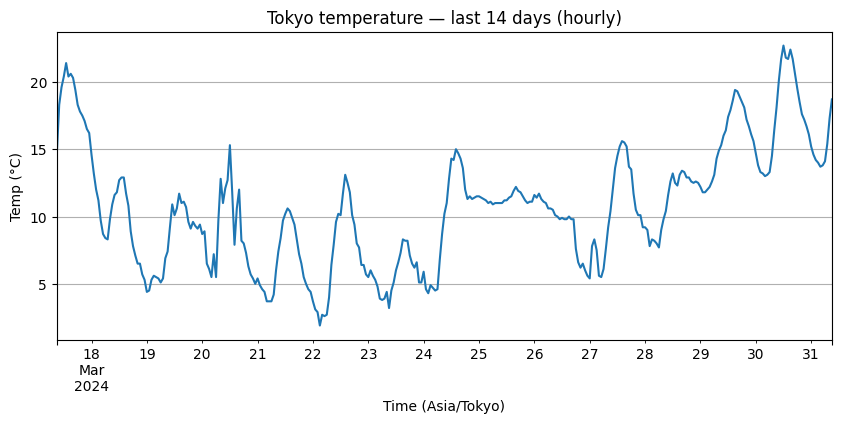

In [6]:
start_date = df.index.max() - pd.Timedelta('14D')
ax = df.loc[df.index >= start_date, 'temp'].plot(title="Tokyo temperature — last 14 days (hourly)")

ax.set_xlabel("Time (Asia/Tokyo)")
ax.set_ylabel("Temp (°C)")
plt.show()

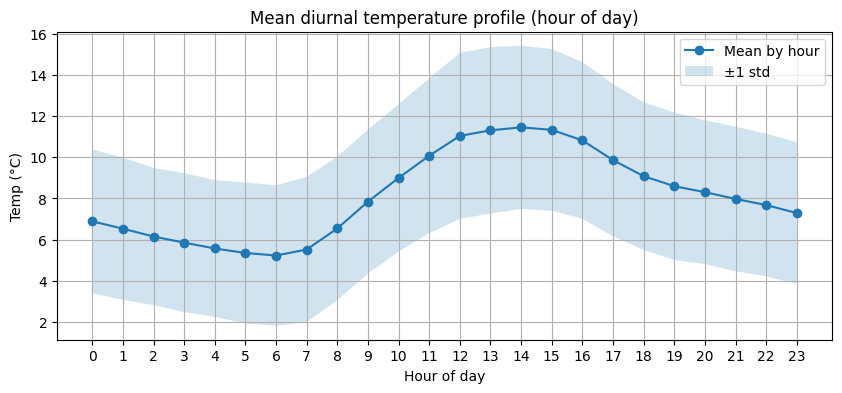

In [7]:
hourly_stats = df['temp'].groupby(df.index.hour).agg(['mean','std'])
hrs = np.arange(24)
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(hrs, hourly_stats['mean'], marker='o', label='Mean by hour')
ax.fill_between(hrs,
                hourly_stats['mean'] - hourly_stats['std'],
                hourly_stats['mean'] + hourly_stats['std'],
                alpha=0.2, label='±1 std')
ax.set_xticks(hrs)
ax.set_title("Mean diurnal temperature profile (hour of day)")
ax.set_xlabel("Hour of day"); ax.set_ylabel("Temp (°C)")
ax.legend()
plt.show()

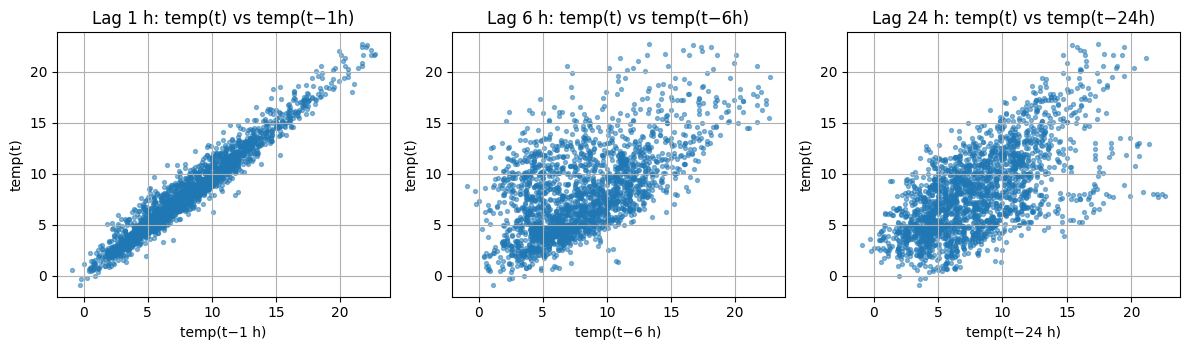

In [8]:
lags = [1, 6, 24]
cols = 3
fig, axes = plt.subplots(1, cols, figsize=(12, 3.6))
for i, L in enumerate(lags):
    ax = axes[i]
    s = df['temp'].dropna()
    aligned = pd.concat([s.shift(L).rename(f"temp(t-{L}h)"), s.rename("temp(t)")], axis=1).dropna()
    ax.scatter(aligned.iloc[:,0], aligned.iloc[:,1], s=8, alpha=0.5)
    ax.set_title(f"Lag {L} h: temp(t) vs temp(t−{L}h)")
    ax.set_xlabel(f"temp(t−{L} h)"); ax.set_ylabel("temp(t)")
plt.tight_layout()
plt.show()

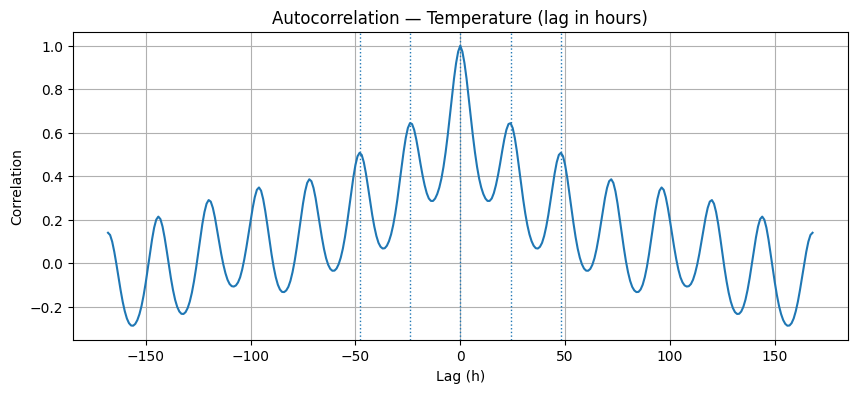

In [9]:
acf_temp = xcorr(df['temp'], df['temp'], max_lag_hours=168)
ax = acf_temp.plot(title="Autocorrelation — Temperature (lag in hours)")
ax.set_xlabel("Lag (h)"); ax.set_ylabel("Correlation")
for k in (-48, -24, 0, 24, 48):
    ax.axvline(k, linestyle=':', linewidth=1)
plt.show()

In [10]:
deadband = 6   # ignore |lag| <= 6 h for "repeating" peaks
win24    = 3   # search window around 24 h (±3 h)

lags = acf_temp.index.values
acf_db = acf_temp.copy()
mask_dead = (lags >= -deadband) & (lags <= deadband)
acf_db.loc[mask_dead] = np.nan

# Global repeating peak (excluding near-zero band)
if acf_db.dropna().empty:
    g_lag = None; g_val = None
else:
    g_lag = int(acf_db.abs().idxmax())
    g_val = float(acf_db.loc[g_lag])

# Peak near ±24 h (if present)
mask24 = (np.abs(np.abs(lags) - 24) <= win24)
acf_24 = acf_db.loc[mask24]
if acf_24.dropna().empty:
    lag_24 = None; val_24 = None
else:
    lag_24 = int(acf_24.abs().idxmax())
    val_24 = float(acf_24.loc[lag_24])

print("Daily ACF summary (robust):")
print(f"  Ignored deadband around 0 h: ±{deadband} h")
print(f"  Global repeating peak (|lag|>{deadband} h): lag={g_lag} h, r={g_val:.2f}" if g_lag is not None else
      "  Global repeating peak: not found (insufficient lags)")
print(f"  Peak near ±24 h (±{win24} h window): lag={lag_24} h, r={val_24:.2f}" if lag_24 is not None else
      "  Peak near ±24 h: not found")

Daily ACF summary (robust):
  Ignored deadband around 0 h: ±6 h
  Global repeating peak (|lag|>6 h): lag=24 h, r=0.64
  Peak near ±24 h (±3 h window): lag=24 h, r=0.64


## Day 5

### Signal & context: Hourly temperature in Tokyo, Japan (Meteostat).

### Use case (WHAT):
Understand recurring daily temperature patterns in Tokyo well enough to support simple, near‑term planning (e.g., comfort, ventilation timing, sea‑breeze awareness) and to set up fair comparisons with other signals in later days.

### Problem statement:
The temperature series contains repeating daily patterns but also day‑to‑day variability.

We need a concise description of that repeat so we can:
- summarize what a “typical day” looks like,
- recognize when a given day deviates from the usual pattern

### Objectives (WHAT to deliver):

Confirm and describe the daily repetition (period and strength) using autocorrelation and simple visuals (done in Day 4).

State a practical target window for interpreting short‑term timing (same‑day effects within ±6 h), distinct from the repeat‑day signal near ±24 h.

Define clear reporting metrics for later days: sign of relationship, peak lag (h), and a one‑sentence, plain‑English interpretation tied to the use case.

### WHY this matters:

A stable daily rhythm means correlation methods will find large peaks near ±24 h; without an explicit use case, those can be misread as causal leads/lags.

By declaring the same‑day window (±6 h) up front, we ensure that later results focus on actionable timing (who moves first within a few hours) rather than on day‑to‑day repetition.

## Day 6

In [11]:
pairs = [("Temp ↔ Humidity", 'temp', 'rhum'),
         ("Temp ↔ Wind",     'temp', 'wspd')]

rows_global, rows_local = [], []
series_for_plots = {}

for name, a, b in pairs:
    s = xcorr(df[a], df[b], max_lag_hours=72)  # z‑norm is inside xcorr
    series_for_plots[name] = s

    # Global peak (often day‑to‑day repetition)
    g_lag = int(s.abs().idxmax())
    g_r   = float(s.loc[g_lag])
    g_sign = "positive" if g_r >= 0 else "negative"
    g_text = (
        f"{b} lags {a} by {g_lag} h (temp leads)" if g_lag > 0 else
        f"{b} leads {a} by {abs(g_lag)} h" if g_lag < 0 else
        "move together (0 h lag)"
    )
    rows_global.append((name, g_sign, g_lag, g_r, g_text))

    # Same‑day (±6 h)
    l_lag, l_r = near_zero_peak(s, 6)
    l_sign = "positive" if l_r >= 0 else "negative"
    l_text = (
        f"{b} lags {a} by {l_lag} h (same‑day)" if l_lag > 0 else
        f"{b} leads {a} by {abs(l_lag)} h (same‑day)" if l_lag < 0 else
        "move together (0 h, same‑day)"
    )
    rows_local.append((name + " (±6 h)", l_sign, l_lag, l_r, l_text))

summary_global = pd.DataFrame(rows_global, columns=["Pair","Sign","Peak lag (h)","Correlation","Interpretation"])
summary_local  = pd.DataFrame(rows_local,  columns=["Pair","Sign","Peak lag (h)","Correlation","Interpretation"])

In [12]:
summary_global

,Pair,Sign,Peak lag (h),Correlation,Interpretation
0,Temp ↔ Humidity,positive,-14,0.282990,rhum leads temp by 14 h
1,Temp ↔ Wind,positive,25,0.249694,wspd lags temp by 25 h (temp leads)


In [13]:
summary_local

,Pair,Sign,Peak lag (h),Correlation,Interpretation
0,Temp ↔ Humidity (±6 h),negative,0,-0.132041,"move together (0 h, same‑day)"
1,Temp ↔ Wind (±6 h),positive,1,0.201061,wspd lags temp by 1 h (same‑day)


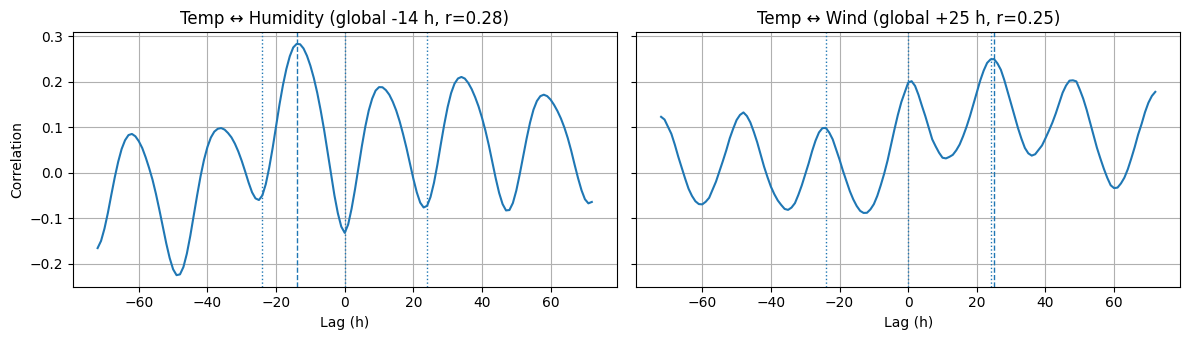

In [14]:
n = len(series_for_plots)
if n:
    cols = 2
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3.5*rows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for i, (name, s) in enumerate(series_for_plots.items()):
        ax = axes[i]
        s.plot(ax=ax)
        for k in (-24, 0, 24):
            ax.axvline(k, linestyle=':', linewidth=1)
        g_lag = s.abs().idxmax()
        ax.axvline(g_lag, linestyle='--', linewidth=1)
        ax.set_title(f"{name} (global {g_lag:+} h, r={s.loc[g_lag]:.2f})")
        ax.set_xlabel("Lag (h)"); ax.set_ylabel("Correlation")

    for j in range(n, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

### Day 7

In [15]:
T_END = df.index.max().floor('h')
T_START = T_END - pd.Timedelta(days=1)
TEMPLATE = df['temp'].loc[T_START:T_END].asfreq('1h').dropna()
print(f"Template window: {T_START} → {T_END}  (length {len(TEMPLATE)} h)")

Template window: 2024-03-30 09:00:00+09:00 → 2024-03-31 09:00:00+09:00  (length 25 h)


In [16]:
SEARCH = df['temp'].last('45d')
# leave room so each sliding window is complete
SEARCH = SEARCH.iloc[:len(SEARCH) - len(TEMPLATE)]
print(f"Search span: {SEARCH.index.min()} → {SEARCH.index.max()}  (length {len(SEARCH)} h)")

Search span: 2024-02-15 10:00:00+09:00 → 2024-03-30 08:00:00+09:00  (length 1055 h)


In [17]:
x = znorm(TEMPLATE).values
vals, idxs = [], []
for i in range(len(SEARCH) - len(TEMPLATE) + 1):
    y = znorm(SEARCH.iloc[i:i+len(TEMPLATE)]).values
    vals.append((x*y).mean())
    idxs.append(SEARCH.index[i])

NCC = pd.Series(vals, index=pd.to_datetime(idxs))
HITS = NCC.sort_values(ascending=False).head(5)
print("Top NCC matches:", HITS)

Top NCC matches: 2024-03-21 09:00:00+09:00    0.945345
2024-03-10 09:00:00+09:00    0.938771
2024-03-09 09:00:00+09:00    0.934063
2024-03-21 08:00:00+09:00    0.931809
2024-03-27 10:00:00+09:00    0.931032
dtype: float64


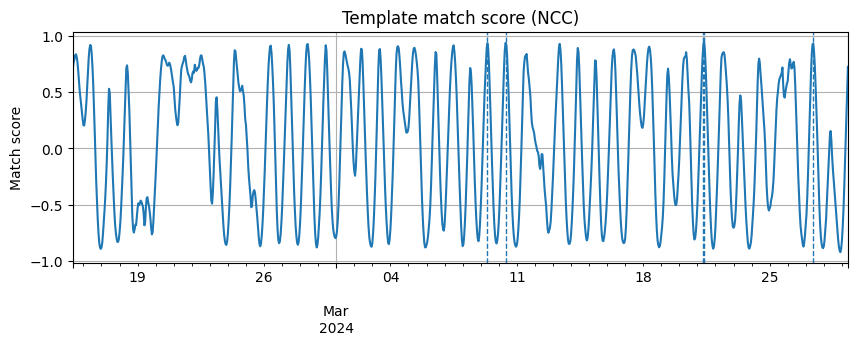

In [18]:
ax = NCC.plot(figsize=(10,3), title="Template match score (NCC)")
ax.set_ylabel("Match score")
for t in HITS.index:
    ax.axvline(t, linestyle='--', linewidth=1)
plt.show()

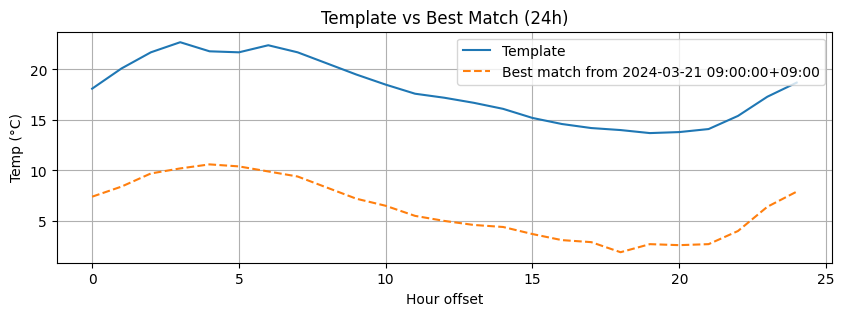

In [19]:
best_t = HITS.index[0]
CAND = df['temp'].loc[best_t:best_t+pd.Timedelta(hours=len(TEMPLATE)-1)].asfreq('1h')
ax = TEMPLATE.reset_index(drop=True).plot(label='Template', figsize=(10,3))
CAND.reset_index(drop=True).plot(ax=ax, style='--', label=f'Best match from {best_t}')
ax.set_title("Template vs Best Match (24h)")
ax.set_xlabel("Hour offset"); ax.set_ylabel("Temp (°C)")
ax.legend()
plt.show()

## Day 8

We test whether detection still works under realistic changes and quantify how scores and match times behave. This expands beyond noise/offset/scale to include outliers, small time shifts (phase), missing chunks (gaps), and template length sensitivity.

In [21]:
rng = np.random.default_rng(0)
base = TEMPLATE.asfreq('1h').dropna()

In [22]:
def add_outliers(s: pd.Series, k:int=3, amp:float=3.0, rng=rng):
    s2 = s.copy()
    idx = rng.choice(np.arange(len(s2)), size=min(k, len(s2)), replace=False)
    s2.iloc[idx] = s2.iloc[idx] + amp * np.sign(rng.standard_normal(len(idx)))
    return s2

def add_gap(s: pd.Series, hours:int=3, start:int=6):
    s2 = s.copy()
    start = min(max(0, start), max(0, len(s2)-hours))
    s2.iloc[start:start+hours] = np.nan
    return s2

In [23]:
def best_ncc(template: pd.Series, search_series: pd.Series):
    t = template.asfreq('1h').dropna()
    if len(t) < 6:
        return np.nan, pd.NaT
    x = znorm(t).values
    vals, idxs = [], []
    for i in range(len(search_series) - len(t) + 1):
        y = znorm(search_series.iloc[i:i+len(t)]).values
        vals.append((x*y).mean())
        idxs.append(search_series.index[i])
    s = pd.Series(vals, index=idxs)
    return float(s.max()), pd.to_datetime(s.idxmax())

In [24]:
variants = {
    'original': base,
    'noise(σ=0.3)': base + rng.normal(0, 0.3, len(base)),               # light sensor noise
    'offset(+1.5°C)': base + 1.5,                                       # warm bias
    'scale(×1.2)': (base - base.mean())*1.2 + base.mean(),              # amplitude change
    'outliers(3×)': add_outliers(base, k=3, amp=3.0),                   # random spikes
    'time_shift(+2h)': base.shift(2),                                   # slight phase shift
    'gap(3h)': add_gap(base, hours=3, start=6),                         # short missing chunk
}

In [25]:
rows = []
for name, t in variants.items():
    score, when = best_ncc(t, SEARCH)
    rows.append((name, score, when))

robust = pd.DataFrame(rows, columns=["Variant","Best score","Time of best match"]).sort_values("Best score", ascending=False)
robust

,Variant,Best score,Time of best match
1,noise(σ=0.3),0.945718,2024-03-21 09:00:00+09:00
5,time_shift(+2h),0.945517,2024-03-21 09:00:00+09:00
0,original,0.945345,2024-03-21 09:00:00+09:00
3,scale(×1.2),0.945345,2024-03-21 09:00:00+09:00
2,offset(+1.5°C),0.945345,2024-03-21 09:00:00+09:00
4,outliers(3×),0.905428,2024-03-27 09:00:00+09:00
6,gap(3h),0.901099,2024-03-21 11:00:00+09:00


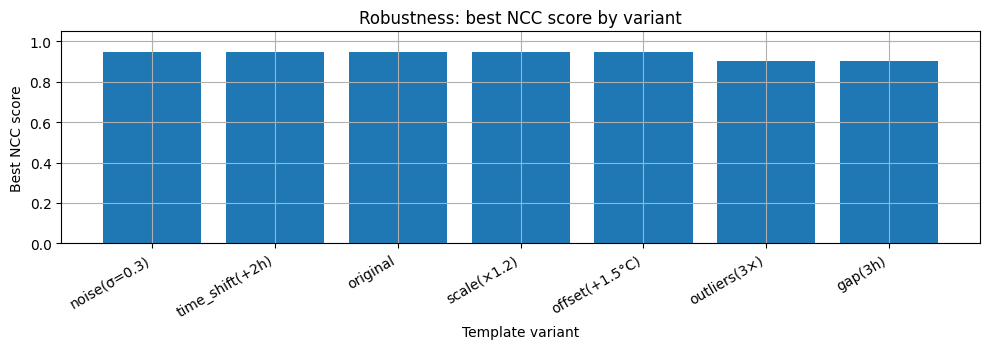

In [26]:
fig, ax = plt.subplots(figsize=(10,3.6))
ax.bar(robust['Variant'], robust['Best score'])
ax.set_ylim(0, 1.05)
ax.set_title("Robustness: best NCC score by variant")
ax.set_ylabel("Best NCC score"); ax.set_xlabel("Template variant")
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

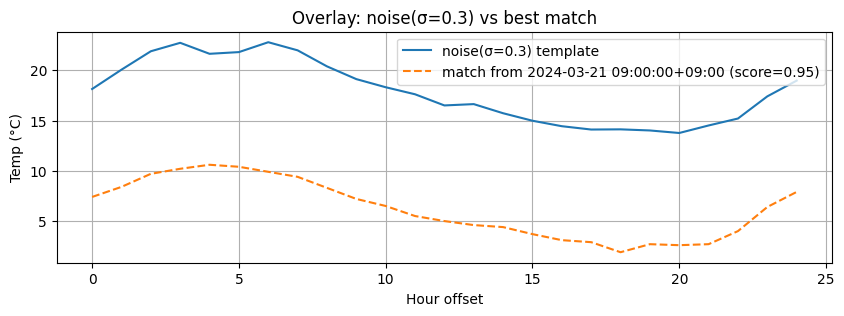

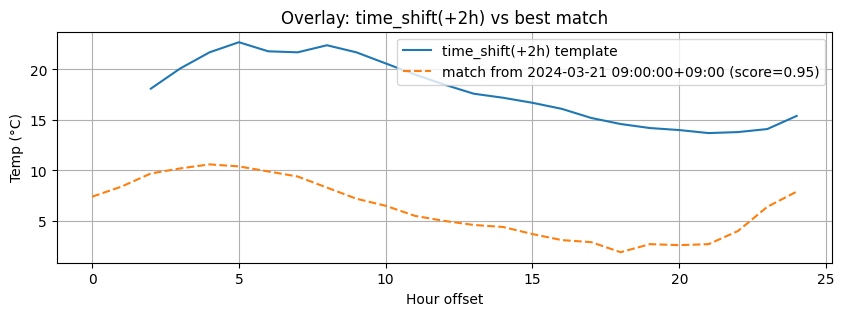

In [27]:
pick = ['noise(σ=0.3)', 'time_shift(+2h)']
for key in pick:
    score, when = best_ncc(variants[key], SEARCH)
    if pd.isna(when):
        continue
    cand = df['temp'].loc[when:when+pd.Timedelta(hours=len(base)-1)].asfreq('1h')
    ax = variants[key].reset_index(drop=True).plot(label=f'{key} template', figsize=(10,3))
    cand.reset_index(drop=True).plot(ax=ax, style='--', label=f'match from {when} (score={score:.2f})')
    ax.set_title(f"Overlay: {key} vs best match")
    ax.set_xlabel("Hour offset"); ax.set_ylabel("Temp (°C)")
    ax.legend()
    plt.show()

In [28]:
lengths = [12, 18, 24, 30, 36]  # hours
rows_len = []
for L in lengths:
    t0 = base.iloc[:L]
    score, when = best_ncc(t0, SEARCH)
    rows_len.append((L, score, when))

len_df = pd.DataFrame(rows_len, columns=["Template length (h)", "Best score", "Time of best match"]).sort_values("Template length (h)")
len_df

,Template length (h),Best score,Time of best match
0,12,0.896045,2024-03-15 09:00:00+09:00
1,18,0.931319,2024-02-20 09:00:00+09:00
2,24,0.945768,2024-03-21 09:00:00+09:00
3,30,0.945345,2024-03-21 09:00:00+09:00
4,36,0.945345,2024-03-21 09:00:00+09:00


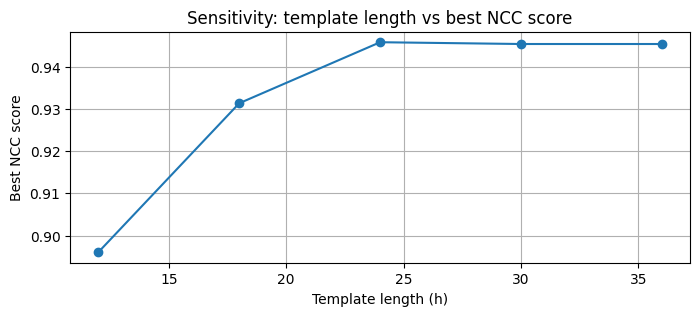

In [29]:
fig, ax = plt.subplots(figsize=(8,3))
ax.plot(len_df['Template length (h)'], len_df['Best score'], marker='o')
ax.set_title("Sensitivity: template length vs best NCC score")
ax.set_xlabel("Template length (h)"); ax.set_ylabel("Best NCC score")
plt.show()

### Stable:
Noise σ≈0.3, +1.5°C offset, ×1.2 scale, and +2h shift all kept best NCC ≈ 0.95 and the same best day → robust to realistic changes.

### Fragile cases:
3 outliers or a 3h gap lowered scores to ~0.90–0.91 and sometimes shifted the match time/day → still usable, but verify with an overlay.

### Best window:
24h template performs best; 18h is workable (≈0.93), 12h is noticeably weaker (≈0.90); 30–36h brings no real gain.

### Quick rule:
Treat NCC ≥ 0.94 as very strong, 0.90–0.94 as good/check overlay, < 0.90 as weak.

### Action:
If you expect spikes/gaps, smooth the template lightly (e.g., median filter) or drop short missing stretches before scoring.

## Day 9

### Methods (why this works for Tokyo):
We used z-normalized NCC on Temp↔Humidity and Temp↔Wind to separate same-day (±6h) coupling from repeat-day (≈±24h) structure, preventing diurnal repetition from being misread as directly aligned with Day 9’s request to discuss method choices relative to the use case.

### Key parameters (and why):
Lag windows: ±72 h (to reveal diurnal aliases) with a ±6h “same-day” window for actionable timing 24h template because ACF showed a strong daily cycle (r≈0.64), and robustness tests ranked 24h > 18h > 12h (30–36h no gain).

### Observations (use-case oriented):
Global XCorr peaks sit near ±24h (daily rhythm), while same-day peaks are weaker but present, matching intuition that short-term coupling exists but is secondary to the diurnal cycle. Template matching finds consistent “typical days,” with highs/lows aligned.

### Interpretation:
For within-day planning in Tokyo (comfort/ventilation/sea-breeze timing), rely on ±6h peaks,they encode modest, actionable leads/lags. Treat ±24 h maxima as repeat-day structure, not causal timing.

### What changes are tolerated (and to what degree):
- Tolerated well: noise σ=0.3, +1.5°C offset, ×1.2 scale, +2h shift → best NCC ≈ 0.95 (same-day).
- Partly tolerated: 3 outliers or a 3 h gap → NCC ≈ 0.90–0.91, with slight match-time drift.
- Less tolerated: shorter templates (12 h) weaken matches (~0.90), longer (30–36h) add no benefit.

### KPIs (concise):
- ACF 24h peak r≈0.64
- robustness NCC ~0.95 (clean perturbations)
- ~0.90–0.91 (outliers/gaps)
- same-day XCorr peaks = weak–moderate vs. stronger ±24h peaks.

### Limitations (brief):
- On highly variable synoptic days, same-day peaks can be small
- segmenting by regime and adding wind-direction/sea-breeze flags could sharpen Temp↔Wind timing.